In [1]:
import argparse
import csv
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import random
import scanpy as sc
from torch.utils.data import DataLoader
from model.model import MIL

In [2]:
from torch.utils.data import Dataset
import pandas as pd
import scanpy as sc
import numpy as np
import torch
import scipy.sparse as sp
from scipy.spatial.distance import cdist
from tqdm import trange
from scipy.sparse import issparse


def preprocess_data(adata, immune_cell, n_genes, resolution):
    # Read the data
    
    if immune_cell not in adata.obs.columns:
        immune_cell = map_immune_cell(immune_cell)
        
    # Ensure adata is not a view
    adata = adata.copy()
    adata.var_names_make_unique()  # Ensure unique gene names

    # Filter the tumor cells
    print(adata.obs['cell_type'].unique())
    tumor_cells = adata[adata.obs['cell_type'].astype(int) == 1].copy()

    # Debug: Check tumor cells
    print(f"Tumor cells shape after filtering: {tumor_cells.shape}")
    if tumor_cells.shape[0] == 0:
        print("Warning: No tumor cells found after filtering.")

    # Calculate mean expression
    if issparse(tumor_cells.X):
        # Convert to dense and compute mean expression
        mean_expression = np.asarray(tumor_cells.X.mean(axis=0)).ravel()
    else:
        mean_expression = tumor_cells.X.mean(axis=0)

    # Get gene names
    gene_names = tumor_cells.var_names

    # Select top n genes
    print(f"Selecting top {n_genes} genes based on mean expression")
    if n_genes > len(gene_names):
        n_genes = int(len(gene_names) * 0.2)
    top_n_gene_indices = mean_expression.argsort()[-n_genes:][::-1]
    top_n_gene_names = gene_names[top_n_gene_indices]
    
    tumor_genes = [
        "Myh6"
    ]
    hla_genes = list(adata.var_names[adata.var_names.str.startswith("H2-")])    
    select_genes=tumor_genes+hla_genes+list(top_n_gene_names)
    existing_genes = [gene for gene in select_genes if gene in adata.var_names]

    genes_to_exclude = [
    "Il2rb", "Ptprc", "Ccl5", "Ets1", "Nkg7", "Coro1a", "Rac2", "Srgn", "Serpina3g",
    "mt-Nd1", "mt-Nd2", "mt-Co1", "mt-Co2", "mt-Atp8", "mt-Atp6", "mt-Co3",
    "mt-Nd3", "mt-Nd4l", "mt-Nd4", "mt-Nd5", "mt-Nd6", "mt-Cytb","Cd8a","Cd8b1", "Hbb-bs",
    "Ccr5", "Dock2", "Ptpn22", "Unc93b1", "C1qa", "Ccr5", "Fabp4"
]

    existing_genes = [gene for gene in existing_genes if gene not in genes_to_exclude]
    
    # Subset adata using gene names to keep indices consistent
    adata = adata[:, existing_genes].copy()

    adata.obs[immune_cell] = adata.obs[immune_cell].astype(float)
    tumor_cells.obs[immune_cell] = tumor_cells.obs[immune_cell].astype(float)

    # Binarize the immune cell column based on the percentile value if resolution is not 'high'
    if resolution != 'high':
        if tumor_cells.obs[immune_cell].empty:
            print(f"Error: tumor_cells.obs[{immune_cell}] is empty.")
        else:
            unique_values = tumor_cells.obs[immune_cell].unique()
            if set(unique_values).issubset({0, 1}):
                print(f"tumor_cells.obs[{immune_cell}] is already binary. Skipping binarization.")
            else:
                percentile_value = np.percentile(tumor_cells.obs[immune_cell], 75)
                print(f"Percentile value: {percentile_value}")
                adata.obs[immune_cell] = np.where(adata.obs[immune_cell] > percentile_value, 1, 0)
                print(f"adata.obs[{immune_cell}] after binarization: {adata.obs[immune_cell].head()}")

    return adata


class BagsDataset(Dataset):
    def __init__(self, input_data, immune_cell, max_instances=None, radius=200, resolution='low', n_genes=500, k=2):
        self.immune_cell = map_immune_cell(immune_cell)
        print(f"Immune cell: {self.immune_cell}")
        self.max_instances = max_instances
        self.radius = radius
        self.resolution = resolution
        self.n_genes = n_genes
        self.k = k  # Number of bags per batch
        if isinstance(input_data, str):
            self.batches = self.create_bags_from_csv(input_data)
        elif isinstance(input_data, sc.AnnData):
            input_data = preprocess_data(input_data, immune_cell, n_genes, self.resolution)
            print(f"Preprocessed data: {input_data.X.shape}")
            self.batches = self.create_bags_from_adata(input_data)
        else:
            raise ValueError("input_data must be either a path to a CSV file or an AnnData object")

    def __len__(self):
        return len(self.batches)

    def __getitem__(self, idx):
        batch = self.batches[idx]
        # batch is a list of bags
        batch_data = []
        for bag in batch:
            distances = bag['distances']
            gene_expression = bag['gene_expression']
            label = bag['label']
            core_idx = bag['core_idx']
            gene_names = bag['gene_names']
            cell_id = bag['cell_id']
            bag_dict = {
                'distances': distances,
                'gene_expression': gene_expression,
                'label': label,
                'core_idx': core_idx,
                'gene_names': gene_names,
                'cell_id': cell_id
            }
            batch_data.append(bag_dict)
        return batch_data

    def create_bags_from_csv(self, csv_file):
        data = pd.read_csv(csv_file)
        adata_radius_list = []
        for _, row in data.iterrows():
            adata_path = row['adata']
            print(f"Reading adata from {adata_path}")
            resolution = row['resolution'] if 'resolution' in row and not pd.isna(row['resolution']) else self.resolution
            adata = sc.read_h5ad(adata_path)
            adata.obs_names_make_unique()
            adata.var_names_make_unique()
            adata = preprocess_data(adata, self.immune_cell, self.n_genes, resolution=resolution)
            radius = row['radius'] if 'radius' in row and not pd.isna(row['radius']) else self.radius
            adata_radius_list.append((adata, radius, resolution))
            print(f"Processing: adata={adata_path.split('/')[-1]}, radius={radius}, resolution={resolution}")
        return self.create_bags(adata_radius_list)

    def create_bags_from_adata(self, adata):
        adata_radius_list = [(adata, self.radius, self.resolution)]
        return self.create_bags(adata_radius_list)

    def create_bags(self, adata_radius_list):
        all_batches = []
        for adata, radius, resolution in adata_radius_list:
            # Collect positive and negative bags per adata
            positive_bags = []
            negative_bags = []
            spatial_coords_x = adata.obs['X'].astype(float)
            spatial_coords_y = adata.obs['Y'].astype(float)
            spatial_coords = np.array(list(zip(spatial_coords_x, spatial_coords_y)))
            gene_expression = adata.X
            labels = adata.obs[self.immune_cell].values.astype(int)  
            adata.obs['cell_type'] = adata.obs['cell_type'].astype(int)
            cell_types = adata.obs['cell_type'].values
            barcodes = adata.obs.index.values  
            gene_names = adata.var_names.tolist()

            for i in trange(len(spatial_coords), desc=f"Creating Bags with radius {radius}", ncols=100):
                if cell_types[i] == 0:
                    continue
                dist_matrix_row = cdist([spatial_coords[i]], spatial_coords, metric='euclidean')[0]
                in_circle = np.where(dist_matrix_row <= radius)[0]
                in_circle = [idx for idx in in_circle if cell_types[idx] == 1]
                num_tumor_cells = len(in_circle)
                if resolution == 'high' and num_tumor_cells < 10:
                    continue
                if resolution == 'high':
                    in_circle = [idx for idx in in_circle if idx != i]
                if len(in_circle) == 0:
                    continue
                if self.max_instances is not None and len(in_circle) > self.max_instances:
                    continue

                gene_data = gene_expression[in_circle]
                distances = np.asmatrix(dist_matrix_row[in_circle].reshape(-1, 1), dtype=np.float32)

                bag = {
                    'distances': distances,
                    'gene_expression': gene_data,
                    'label': labels[i],
                    'core_idx': i,
                    'gene_names': gene_names,
                    'cell_id': barcodes[i]
                }

                if labels[i] == 1:
                    positive_bags.append(bag)
                else:
                    negative_bags.append(bag)

            num_negative_per_batch = self.k - 1
            if len(negative_bags) < num_negative_per_batch:
                print(f"Not enough negative bags in this adata to create batches. Dropping extra positive bags.")
                num_batches = len(negative_bags) // num_negative_per_batch
                if num_batches == 0:
                    continue 
                if len(positive_bags) > num_batches:
                    positive_bags = positive_bags[:num_batches]
            else:
                num_batches = min(len(positive_bags), len(negative_bags) // num_negative_per_batch)
                if len(positive_bags) > num_batches:
                    positive_bags = positive_bags[:num_batches]
                if len(negative_bags) > num_batches * num_negative_per_batch:
                    negative_bags = negative_bags[:num_batches * num_negative_per_batch]
        
            np.random.shuffle(negative_bags)

            for i in range(num_batches):
                batch = [positive_bags[i]] + negative_bags[i * num_negative_per_batch: (i + 1) * num_negative_per_batch]
                all_batches.append(batch)

        total_batches = len(all_batches)
        print(f"Total batches created: {total_batches}")
        return all_batches



def custom_collate_fn(batch):
    
    batch_bags = batch[0]
    distances_list = []
    gene_expressions_list = []
    labels_list = []
    core_idxs_list = []
    gene_names_list = []
    cell_ids_list = []
    for bag_data in batch_bags:
        distances = torch.tensor(bag_data['distances'], dtype=torch.float32)
        gene_expression = bag_data['gene_expression']
        if sp.issparse(gene_expression):
            gene_expression = torch.tensor(gene_expression.todense(), dtype=torch.float32)
        else:
            gene_expression = torch.tensor(gene_expression, dtype=torch.float32)
        label = torch.tensor(bag_data['label'], dtype=torch.float32)
        core_idx = bag_data['core_idx']
        gene_names = bag_data['gene_names']
        cell_id = bag_data['cell_id']
        distances_list.append(distances)
        gene_expressions_list.append(gene_expression)
        labels_list.append(label)
        core_idxs_list.append(core_idx)
        gene_names_list.append(gene_names)
        cell_ids_list.append(cell_id)
    return distances_list, gene_expressions_list, labels_list, core_idxs_list, gene_names_list, cell_ids_list



def map_immune_cell(immune_cell):
    mapping = {
        'tcell': 'T',
        'bcell': 'B',
        'macrophage': 'Macrophage',
        'neutrophil': 'Neutrophil',
        'fibroblast': 'Fibroblast',
        'endothelial': 'Endothelial',
    }
    if immune_cell in mapping:
        return mapping[immune_cell]
    else:
        raise ValueError('Invalid immune cell type')


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
def load_all_genes(reference_gene_file):
    all_genes = []
    with open(reference_gene_file, 'r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            all_genes.append(row['Gene'])
    return all_genes

all_genes = load_all_genes('data/all_mouse_genes.csv')

In [7]:
model_path = 'mouse_heart/tcell/model_epoch_5.pth'
all_genes_df = pd.read_csv('data/all_mouse_genes.csv')  # Replace with your reference gene file path
all_genes = all_genes_df['Gene'].tolist()

# Initialize the model
model = MIL(all_genes).to(device)

In [8]:
model.load_state_dict(torch.load(model_path, map_location=device))


<All keys matched successfully>

In [9]:
model.state_dict()

OrderedDict([('alpha', tensor(2.5508)),
             ('beta', tensor(-3.6651)),
             ('distance.a', tensor(-6.4926)),
             ('gene_expression.b', tensor(4.3477)),
             ('immunogenicity.ig',
              tensor([-0.0582, -0.0582, -0.0582,  ..., -0.0582, -0.0582, -0.0582]))])

In [10]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from model.dataset import BagsDataset, custom_collate_fn


In [11]:

# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [12]:

# Load the list of all genes used during training
all_genes_df = pd.read_csv('data/all_mouse_genes.csv')  # Replace with your reference gene file path
all_genes = all_genes_df['Gene'].tolist()


In [24]:

# Load the prediction dataset
adata = sc.read('/project/DPDS/Wang_lab/s439765/spatial_tcr/MIL_TCR/data/hyun/vonly/female_processed_vonlyT.h5ad')
prediction_dataset = BagsDataset(adata, immune_cell='tcell', radius=150, n_genes=3000, resolution='high',k=2,max_instances=500)
prediction_dataloader = torch.utils.data.DataLoader(prediction_dataset, batch_size=1, collate_fn=custom_collate_fn)
adata.obs['T_pred'] = np.nan


Immune cell: T
[0 1 2]
Tumor cells shape after filtering: (117992, 18472)
Selecting top 3000 genes based on mean expression
Preprocessed data: (167186, 3000)


Creating Bags with radius 150: 100%|██████████████████████| 167186/167186 [02:02<00:00, 1361.57it/s]

Total batches created: 528


In [25]:
import torch

def predict(model, prediction_dataloader, adata, device='cuda'):
    """
    Perform prediction/inference using the given model and dataloader, and store
    the predictions in `adata.obs`.

    Args:
        model (nn.Module): The trained model to use for inference.
        prediction_dataloader (DataLoader): Dataloader that yields batches of
            (distances_list, gene_expressions_list, labels_list, core_idxs_list,
             gene_names_list, cell_ids_list).
        adata (AnnData): The annotated data object where predictions will be stored.
        device (str, optional): The device to run predictions on. Default is 'cuda'.

    Returns:
        None. The predictions are stored in `adata.obs` under the column 'T_pred'.
    """

    model.eval()
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    print(f"Using device for prediction: {device}")

    with torch.no_grad():
        for batch_data in prediction_dataloader:
            # Unpack the batch. Each batch contains lists of tensors/objects:
            # distances_list, gene_expressions_list, labels_list, core_idxs_list,
            # gene_names_list, cell_ids_list.
            (
                distances_list, 
                gene_expressions_list, 
                labels_list,        # Might not be needed for inference, but still returned.
                core_idxs_list, 
                gene_names_list, 
                cell_ids_list
            ) = batch_data

            # Move data to the appropriate device (GPU or CPU).
            distances_list = [distances.to(device) for distances in distances_list]
            gene_expressions_list = [gene_exp.to(device) for gene_exp in gene_expressions_list]

            # Forward pass through the model.
            outputs = model(distances_list, gene_expressions_list, gene_names_list)

            # If the model returns None (e.g., due to skipping certain batches), skip them.
            if outputs is None:
                continue

           
            for output, cell_id in zip(outputs, cell_ids_list):
                # Detach from GPU and convert to Python float.
                prediction = output.cpu().item()
                # Store the prediction in adata.obs using the matching cell_id.
                adata.obs.loc[cell_id, 'T_pred'] = prediction
                print(f"cell_id={cell_id}, prediction={prediction}")


In [26]:
predict(model, prediction_dataloader, adata)

Using device for prediction: cpu
cell_id=s_008um_00591_00195-1, prediction=0.6364834904670715
cell_id=s_008um_00552_00250-1, prediction=0.35125038027763367
cell_id=s_008um_00683_00366-1, prediction=0.6502324342727661
cell_id=s_008um_00636_00103-1, prediction=0.3965984284877777
cell_id=s_008um_00675_00533-1, prediction=0.6529330015182495
cell_id=s_008um_00631_00080-1, prediction=0.407173216342926
cell_id=s_008um_00504_00519-1, prediction=0.7689493298530579
cell_id=s_008um_00718_00486-1, prediction=0.7578355669975281
cell_id=s_008um_00661_00460-1, prediction=0.4675103724002838
cell_id=s_008um_00591_00399-1, prediction=0.25770488381385803
cell_id=s_008um_00592_00195-1, prediction=0.6408208012580872
cell_id=s_008um_00651_00045-1, prediction=0.24220649898052216
cell_id=s_008um_00506_00519-1, prediction=0.7701085805892944
cell_id=s_008um_00621_00101-1, prediction=0.4254220128059387
cell_id=s_008um_00552_00258-1, prediction=0.3294675648212433
cell_id=s_008um_00494_00316-1, prediction=0.406601

In [27]:
adata.obs

,cell_type_string,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,X,Y,cell_type,T,T_pred
s_008um_00789_00234-1,Brown Adipocytes,789,234,20959.534025,11095.274122,936,3156,0,0,NaN
s_008um_00681_00396-1,Atrial CM,681,396,18112.370635,7095.397976,1584,2724,0,0,NaN
s_008um_00128_00278-1,Ventricular CM,128,278,4264.335318,10497.531042,1112,512,1,0,NaN
s_008um_00516_00369-1,Valve Interstitial Cells,516,369,13974.314108,7903.569830,1476,2064,0,0,NaN
s_008um_00447_00253-1,Ventricular CM,447,253,12324.596597,10880.928040,1012,1788,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...
s_008um_00580_00029-1,Ventricular CM,580,29,15849.828611,16424.404948,116,2320,1,0,NaN
s_008um_00260_00044-1,Ventricular CM,260,44,7772.158974,16293.999941,176,1040,1,0,NaN
s_008um_00618_00434-1,Atrial CM,618,434,16495.121825,6186.279184,1736,2472,0,0,NaN
s_008um_00808_00300-1,Endocardial Cells,808,300,21387.478842,9416.966010,1200,3232,0,0,NaN


In [28]:
mask = ~adata.obs['T_pred'].isna()
adata = adata[mask].copy()

In [29]:
adata.obs['T'].value_counts()   

T
1    528
0    528
Name: count, dtype: int64

In [30]:
#auroc 
from sklearn.metrics import roc_auc_score
roc_auc_score(adata.obs['T'], adata.obs['T_pred'])


0.6757669019742883

In [33]:
#binarize the prediction,percentile is 0.5 as threshold, <0.5 as 0,>0.5 as 1
threshold_val = np.percentile(adata.obs['T_pred'], 50)
print(f"Threshold value: {threshold_val}")
adata.obs['T_pred_binary'] = (adata.obs['T_pred'] > threshold_val).astype(int)


Threshold value: 0.4637572765350342


In [34]:
adata.obs['T_pred_binary'].value_counts()

T_pred_binary
1    528
0    528
Name: count, dtype: int64

In [35]:
adata.obs

,cell_type_string,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,X,Y,cell_type,T,T_pred,T_pred_binary
s_008um_00591_00195-1,Treg Cells,591,195,15998.999213,12231.519396,780,2364,2,1,0.636483,1
s_008um_00630_00111-1,Ventricular CM,630,111,17046.838922,14318.720611,444,2520,1,0,0.427657,0
s_008um_00683_00366-1,Treg Cells,683,366,18185.932918,7850.036707,1464,2732,2,1,0.650232,1
s_008um_00675_00533-1,Treg Cells,675,533,17855.414088,3646.818026,2132,2700,2,1,0.652933,1
s_008um_00505_00309-1,Ventricular CM,505,309,13743.342328,9424.476585,1236,2020,1,0,0.409192,0
...,...,...,...,...,...,...,...,...,...,...,...
s_008um_00534_00290-1,CD8 T Cells,534,290,14488.970762,9880.972332,1160,2136,2,1,0.321971,0
s_008um_00721_00490-1,CD8 T Cells,721,490,19048.021457,4695.107836,1960,2884,2,1,0.735975,1
s_008um_00647_00042-1,CD8 T Cells,647,42,17528.582142,16044.848808,168,2588,2,1,0.255928,0
s_008um_00637_00070-1,CD8 T Cells,637,70,17254.917989,15346.790630,280,2548,2,1,0.368211,0


In [36]:
adata.write_h5ad('./validation_heart/diff_gene/female.h5ad')

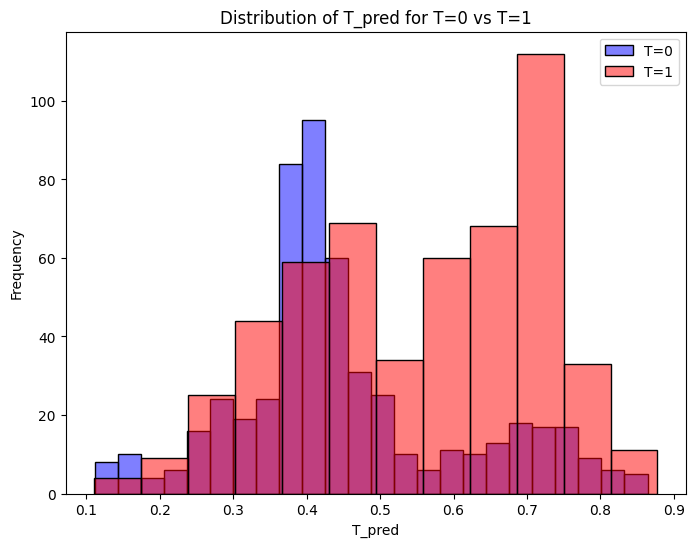

In [31]:
df = adata.obs.dropna(subset=['T_pred', 'T']).copy()
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.histplot(df.loc[df['T'] == 0, 'T_pred'], 
             color='blue', alpha=0.5, label='T=0')
sns.histplot(df.loc[df['T'] == 1, 'T_pred'], 
             color='red', alpha=0.5, label='T=1')
plt.legend()
plt.xlabel('T_pred')
plt.ylabel('Frequency')
plt.title('Distribution of T_pred for T=0 vs T=1')
plt.show()

最优阈值: 0.474
Youden's J statistic: 0.354


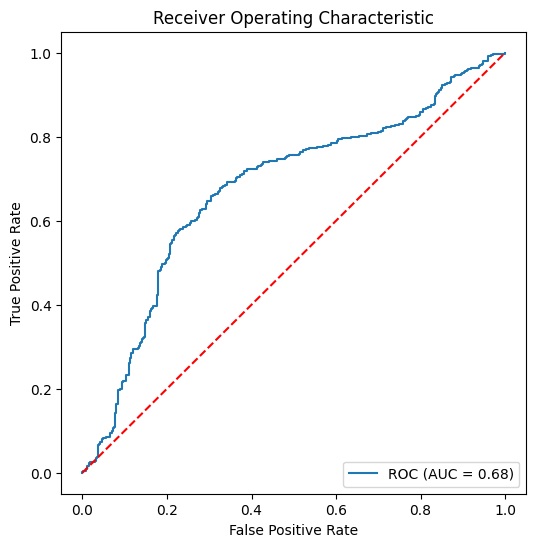

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

df = adata.obs.dropna(subset=['T_pred', 'T']).copy()
df['T'] = df['T'].astype(int)

y_true = df['T']
y_score = df['T_pred']

# 计算 ROC 曲线各点以及 AUC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Youden’s J = TPR - FPR，取最大时对应的阈值
youdenJ = tpr - fpr
ix = np.argmax(youdenJ)
best_thresh = thresholds[ix]

print(f'最优阈值: {best_thresh:.3f}')
print(f'Youden\'s J statistic: {youdenJ[ix]:.3f}')

# 绘制 ROC 曲线
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label='ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


In [23]:
best_thresh

0.8765764832496643

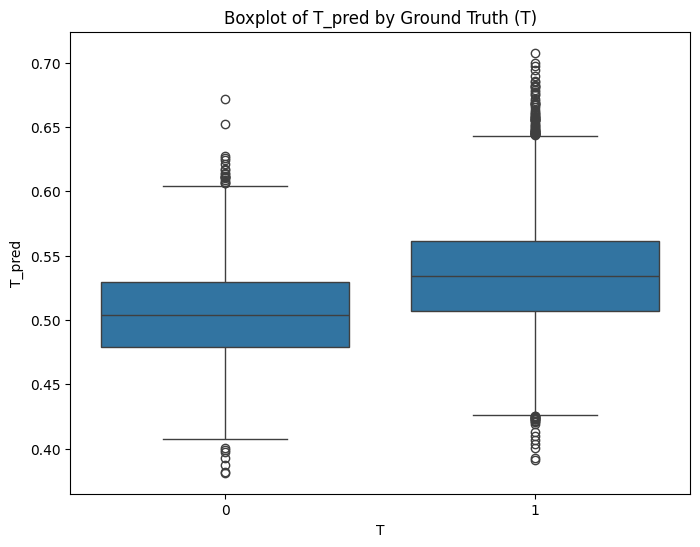

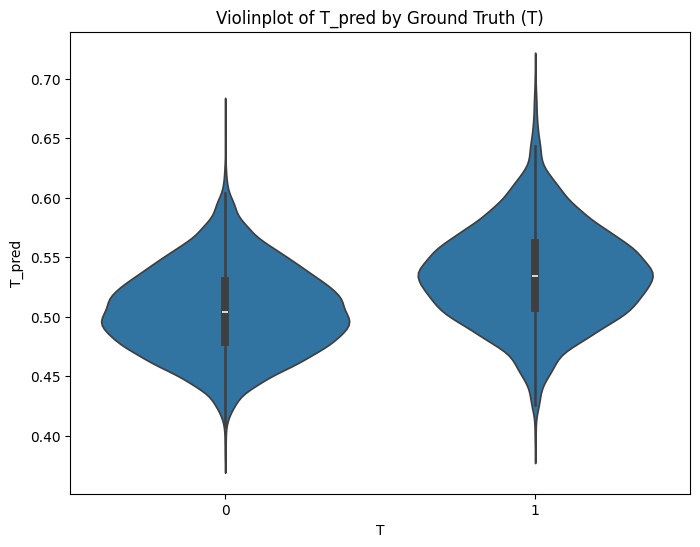

In [43]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='T', y='T_pred')
plt.title('Boxplot of T_pred by Ground Truth (T)')
plt.show()

# 或者小提琴图
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='T', y='T_pred')
plt.title('Violinplot of T_pred by Ground Truth (T)')
plt.show()